In [1]:
import pickle
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import h5py
import os
from tqdm import tqdm

root_path = "./Parse_10M_PBMC_cytokines.h5ad"
parse_full = ad.read_h5ad(root_path)

In [2]:
parse_full.obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,bc3_well,log1p_n_genes_by_counts,log1p_total_counts,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type
89_103_005__s1,Donor10_4-1BBL,hg38,2236,4700,8656,89,103,5,H5,p2.A7,A5,7.712891,8.455530,56.0,1.191490,4.043051,Donor10,4-1BBL,cytokine,CD8 Naive
89_103_083__s1,Donor10_4-1BBL,hg38,2222,4337,8235,89,103,83,H5,p2.A7,G11,7.706613,8.375169,71.0,1.637076,4.276666,Donor10,4-1BBL,cytokine,B Naive
89_103_085__s1,Donor10_4-1BBL,hg38,1690,3079,5870,89,103,85,H5,p2.A7,H1,7.433075,8.032685,197.0,6.398181,5.288267,Donor10,4-1BBL,cytokine,B Intermediate/Memory
89_104_009__s1,Donor10_4-1BBL,hg38,1746,3015,5663,89,104,9,H5,p2.A8,A9,7.465655,8.011686,84.0,2.786070,4.442651,Donor10,4-1BBL,cytokine,CD14 Mono
89_104_025__s1,Donor10_4-1BBL,hg38,3182,6986,13153,89,104,25,H5,p2.A8,C1,8.065579,8.851807,165.0,2.361867,5.111988,Donor10,4-1BBL,cytokine,CD14 Mono
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61_186_093__s144,Donor9_VEGF,hg38,1439,2381,4989,61,186,93,F1,p2.H6,H9,7.272398,7.775696,43.0,1.805964,3.784190,Donor9,VEGF,cytokine,CD4 Memory
61_186_108__s144,Donor9_VEGF,hg38,1962,3457,7093,61,186,108,F1,p2.H6,p2.A12,7.582229,8.148446,85.0,2.458779,4.454347,Donor9,VEGF,cytokine,CD14 Mono
61_186_135__s144,Donor9_VEGF,hg38,1589,2785,5983,61,186,135,F1,p2.H6,p2.D3,7.371489,7.932362,49.0,1.759426,3.912023,Donor9,VEGF,cytokine,CD8 Naive
61_186_157__s144,Donor9_VEGF,hg38,1819,3342,7088,61,186,157,F1,p2.H6,p2.F1,7.506592,8.114624,54.0,1.615799,4.007333,Donor9,VEGF,cytokine,CD8 Naive


In [ ]:

# # clean cell types to remove from dataset
# mask = parse_full.obs["cell_type"].isin(["Plasmablast", "ILC"])
# parse_full = parse_full[~mask].copy()
# parse_full.obs


,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,bc3_well,log1p_n_genes_by_counts,log1p_total_counts,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type
89_103_005__s1,Donor10_4-1BBL,hg38,2236,4700,8656,89,103,5,H5,p2.A7,A5,7.712891,8.455530,56.0,1.191490,4.043051,Donor10,4-1BBL,cytokine,CD8 Naive
89_103_083__s1,Donor10_4-1BBL,hg38,2222,4337,8235,89,103,83,H5,p2.A7,G11,7.706613,8.375169,71.0,1.637076,4.276666,Donor10,4-1BBL,cytokine,B Naive
89_103_085__s1,Donor10_4-1BBL,hg38,1690,3079,5870,89,103,85,H5,p2.A7,H1,7.433075,8.032685,197.0,6.398181,5.288267,Donor10,4-1BBL,cytokine,B Intermediate/Memory
89_104_009__s1,Donor10_4-1BBL,hg38,1746,3015,5663,89,104,9,H5,p2.A8,A9,7.465655,8.011686,84.0,2.786070,4.442651,Donor10,4-1BBL,cytokine,CD14 Mono
89_104_025__s1,Donor10_4-1BBL,hg38,3182,6986,13153,89,104,25,H5,p2.A8,C1,8.065579,8.851807,165.0,2.361867,5.111988,Donor10,4-1BBL,cytokine,CD14 Mono
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61_186_093__s144,Donor9_VEGF,hg38,1439,2381,4989,61,186,93,F1,p2.H6,H9,7.272398,7.775696,43.0,1.805964,3.784190,Donor9,VEGF,cytokine,CD4 Memory
61_186_108__s144,Donor9_VEGF,hg38,1962,3457,7093,61,186,108,F1,p2.H6,p2.A12,7.582229,8.148446,85.0,2.458779,4.454347,Donor9,VEGF,cytokine,CD14 Mono
61_186_135__s144,Donor9_VEGF,hg38,1589,2785,5983,61,186,135,F1,p2.H6,p2.D3,7.371489,7.932362,49.0,1.759426,3.912023,Donor9,VEGF,cytokine,CD8 Naive
61_186_157__s144,Donor9_VEGF,hg38,1819,3342,7088,61,186,157,F1,p2.H6,p2.F1,7.506592,8.114624,54.0,1.615799,4.007333,Donor9,VEGF,cytokine,CD8 Naive


In [3]:
print("[1/2] Prepare adata.var...")
pkl_path = "/mnt/shared-storage-gpfs2/beam-gpfs02/yulang/master/nemo_cellflow/preprocessing/arcinstitute/collections/ST_Parse/var_dims.pkl"
with open(pkl_path, "rb") as f:
    var_dims = pickle.load(f)
gene_names = [name for name in var_dims['gene_names']]
var = pd.DataFrame(index=gene_names)

[1/2] Prepare adata.var...


In [4]:
print("[2/2] hvg adata")

adata = parse_full[:,var_dims['gene_names']].copy()

Xs = adata.X
obs = adata.obs
vars = var

new_adata = ad.AnnData(X=Xs, obs=obs, var=vars)
print("[sc.pp operations]")
sc.pp.normalize_total(new_adata, target_sum=1e4)           
sc.pp.log1p(new_adata)
new_adata.write_h5ad(f"./only_hvg/PBMC_only_hvg.h5ad")



[2/2] hvg adata
[sc.pp operations]


n_obs=9,683,742，绘图/检验将随机抽样 200,000 个细胞
raw 来源: parse_full(in-memory)[:, HVG]
x_raw=log10(raw_lib+1):  p50=2.3201, p99=3.6357
x_proc=log10(proc_lib+1): p50=2.3304, p99=9.3670


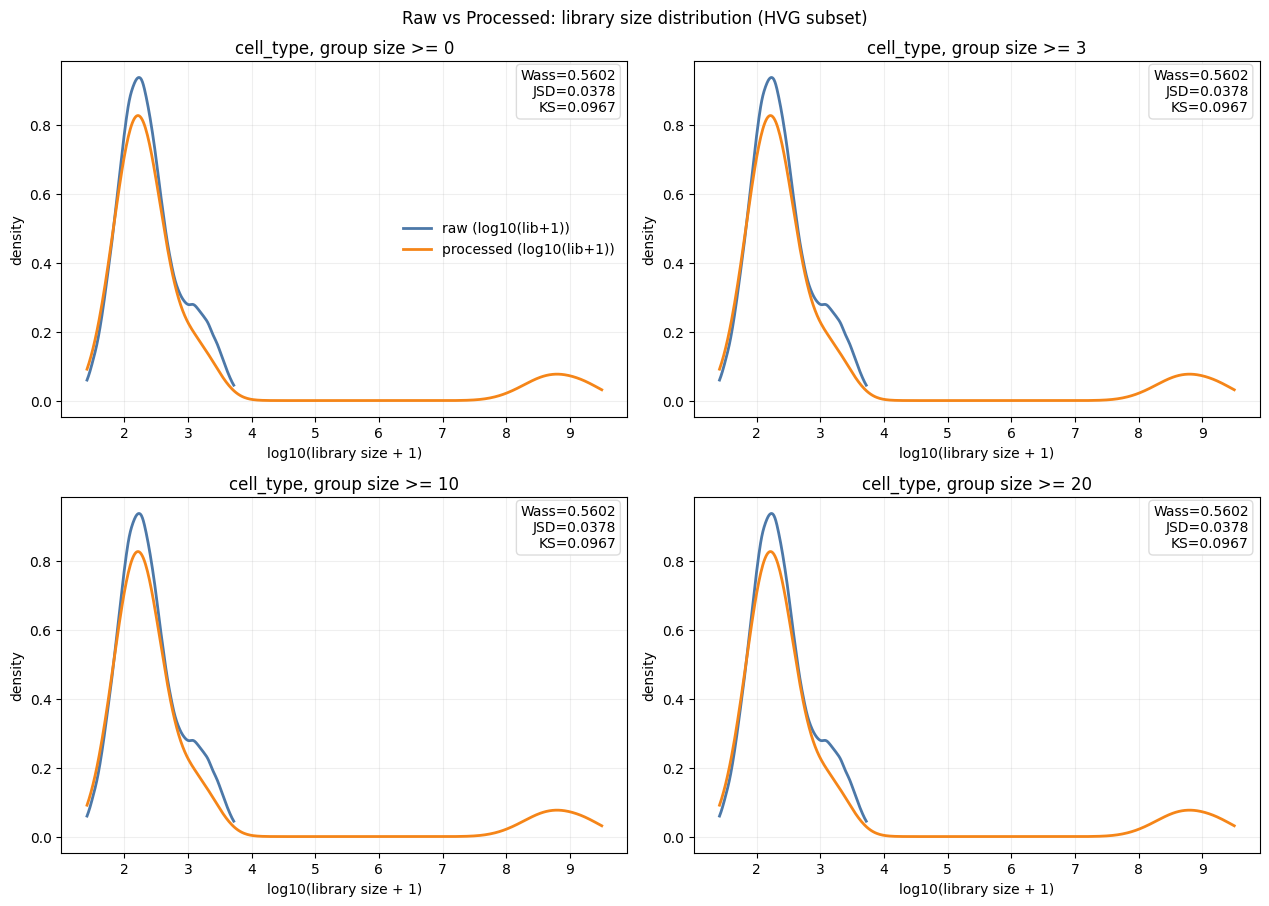

In [12]:
# ===== 图1风格：HVG library size（每细胞总表达量）raw vs processed =====
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import scipy.stats as stats
import matplotlib.pyplot as plt

hvg_path = "./only_hvg/PBMC_only_hvg_norm_exclude_high_no_plasmablast_ilc.h5ad"
root_path = "./Parse_10M_PBMC_cytokines.h5ad"

# 你可以改这里：按哪个 obs 字段做 group size 过滤；None 表示不按组过滤
# 例："cell_type" / "donor" / "cytokine" / "treatment"
group_key = "cell_type" if "cell_type" in sc.read_h5ad(hvg_path, backed="r").obs_keys() else None
thresholds = [0, 3, 10, 20]

# 避免超大数据绘图卡死：只对绘图/统计抽样
max_cells_for_plots = 200_000
rng = np.random.default_rng(0)

new_adata = sc.read_h5ad(hvg_path)
if new_adata.n_obs > max_cells_for_plots:
    sel = np.sort(rng.choice(new_adata.n_obs, size=max_cells_for_plots, replace=False))
    plot_adata = new_adata[sel].copy()
    print(f"n_obs={new_adata.n_obs:,}，绘图/检验将随机抽样 {max_cells_for_plots:,} 个细胞")
else:
    plot_adata = new_adata


def per_cell_sum(x):
    return np.asarray(x.sum(axis=1)).ravel()


def sum_expm1_log1p_matrix(x):
    # x 是 log1p 后的矩阵；返回每个细胞 expm1(x) 的总和（近似归一化后的 library size）
    if sp.issparse(x):
        y = x.copy()
        y.data = np.expm1(y.data)
        return per_cell_sum(y)
    return per_cell_sum(np.expm1(x))


def jsd_from_hist(a, b, bins=200, eps=1e-12):
    lo = float(min(a.min(), b.min()))
    hi = float(max(a.max(), b.max()))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return np.nan
    pa, _ = np.histogram(a, bins=bins, range=(lo, hi), density=True)
    pb, _ = np.histogram(b, bins=bins, range=(lo, hi), density=True)
    pa = pa + eps
    pb = pb + eps
    pa = pa / pa.sum()
    pb = pb / pb.sum()
    m = 0.5 * (pa + pb)
    return 0.5 * (stats.entropy(pa, m) + stats.entropy(pb, m))


def kde_line(ax, x, color, label, lw=2):
    if x.size < 2:
        return
    kde = stats.gaussian_kde(x)
    lo, hi = np.percentile(x, [0.5, 99.5])
    if lo == hi:
        lo, hi = x.min(), x.max() + 1e-6
    grid = np.linspace(lo, hi, 512)
    ax.plot(grid, kde(grid), color=color, lw=lw, label=label)


# 原始 HVG（优先 raw，其次 counts layer；否则从 parse_full 重建）
raw_X = None
raw_source = None
if plot_adata.raw is not None:
    raw_X = plot_adata.raw.X
    raw_source = "new_adata.raw.X"
elif "counts" in plot_adata.layers:
    raw_X = plot_adata.layers["counts"]
    raw_source = "new_adata.layers['counts']"
else:
    parse_obj = globals().get("parse_full", None)
    if parse_obj is None:
        parse_obj = ad.read_h5ad(root_path, backed="r")
        raw_source = "parse_full(backed)[:, HVG]"
    else:
        raw_source = "parse_full(in-memory)[:, HVG]"

    common_cells = plot_adata.obs_names.intersection(parse_obj.obs_names)
    common_genes = plot_adata.var_names.intersection(parse_obj.var_names)
    if len(common_cells) != plot_adata.n_obs or len(common_genes) != plot_adata.n_vars:
        print(
            f"对齐提示：plot_adata cells={plot_adata.n_obs:,}, genes={plot_adata.n_vars:,}; "
            f"common cells={len(common_cells):,}, common genes={len(common_genes):,}"
        )
    plot_adata = plot_adata[common_cells, common_genes].copy()
    raw_X = parse_obj[common_cells, common_genes].X

raw_lib = per_cell_sum(raw_X)  # counts library size（HVG子集）
proc_lib = sum_expm1_log1p_matrix(plot_adata.X)  # 还原到 normalize_total 后的“计数尺度”再求和

x_raw = np.log10(raw_lib + 1.0)
x_proc = np.log10(proc_lib + 1.0)

print(f"raw 来源: {raw_source}")
print(f"x_raw=log10(raw_lib+1):  p50={np.percentile(x_raw,50):.4f}, p99={np.percentile(x_raw,99):.4f}")
print(f"x_proc=log10(proc_lib+1): p50={np.percentile(x_proc,50):.4f}, p99={np.percentile(x_proc,99):.4f}")

# group size 过滤掩码
if group_key is None:
    groups = None
    group_sizes = None
else:
    groups = plot_adata.obs[group_key].astype("category")
    group_sizes = groups.value_counts()

n_panels = len(thresholds)
rows = int(np.ceil(n_panels / 2))
cols = 2 if n_panels > 1 else 1
fig, axes = plt.subplots(rows, cols, figsize=(12.8, 4.6 * rows), squeeze=False)
fig.suptitle("Raw vs Processed: library size distribution (HVG subset)")

for i, thr in enumerate(thresholds):
    ax = axes[i // cols, i % cols]

    if group_key is None:
        mask = np.ones(plot_adata.n_obs, dtype=bool)
        subtitle = "all cells"
    else:
        keep_groups = group_sizes[group_sizes >= thr].index
        mask = groups.isin(keep_groups).to_numpy()
        subtitle = f"{group_key}, group size >= {thr}"

    a = x_raw[mask]
    b = x_proc[mask]

    # 指标
    wass = stats.wasserstein_distance(a, b) if a.size and b.size else np.nan
    jsd = jsd_from_hist(a, b, bins=220)
    ks = stats.ks_2samp(a, b).statistic if a.size and b.size else np.nan

    # 曲线
    kde_line(ax, a, color="#4C78A8", label="raw (log10(lib+1))")
    kde_line(ax, b, color="#F58518", label="processed (log10(lib+1))")

    ax.set_title(subtitle)
    ax.set_xlabel("log10(library size + 1)")
    ax.set_ylabel("density")
    ax.grid(True, alpha=0.2)

    ax.text(
        0.98,
        0.98,
        f"Wass={wass:.4f}\nJSD={jsd:.4f}\nKS={ks:.4f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.85", alpha=0.9),
    )

    if i == 0:
        ax.legend(frameon=False)

# 多余子图隐藏
for j in range(n_panels, rows * cols):
    axes[j // cols, j % cols].axis("off")

plt.tight_layout()
plt.show()

In [5]:
new_adata.X.max()

9.006636